In [6]:
import sys
print(sys.version)
print(sys.executable)

3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.6.3.2)]
/Users/mac/Desktop/project /.venv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

os.makedirs('../reports/summary_stats', exist_ok=True)

In [4]:
df_raw = pd.read_csv('../data/raw/retail_online_ii.csv')

In [5]:
print(f"dataset shape:{df_raw.shape}")
print(f"Data range: {df_raw['InvoiceDate'].min()} to {df_raw['InvoiceDate'].max()}")
print(f"Unique product: {df_raw['StockCode'].nunique()}")
print(f"unique customers: {df_raw['Customer ID'].nunique()}")
print(f"unique countries: {df_raw['Country'].nunique()}")

dataset shape:(525461, 8)
Data range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Unique product: 4632
unique customers: 4383
unique countries: 40


In [6]:
df_raw.head(10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [18]:
df_raw['StockCode'].value_counts().head(20)

StockCode
85123A    3516
22423     2221
85099B    2057
21212     1933
21232     1843
20725     1620
84879     1458
84991     1400
21754     1386
20914     1276
21034     1232
21931     1220
21080     1209
22139     1203
21977     1196
22383     1192
22138     1180
20727     1179
82494L    1165
22470     1154
Name: count, dtype: int64

In [19]:
df_raw['StockCode'].value_counts().tail(20)

StockCode
35004p    1
85179a    1
90214U    1
85017D    1
90176B    1
15002     1
90142C    1
47590b    1
90127A    1
90142B    1
90135     1
90136     1
90142D    1
84596g    1
90182A    1
85049g    1
72803b    1
79151B    1
22933     1
21120     1
Name: count, dtype: int64

In [20]:
df_raw[~df_raw['StockCode'].str.contains(r'\d', na=False)]['StockCode'].value_counts()

StockCode
POST            865
M               850
DOT             736
D               100
ADJUST           67
BANK CHARGES     65
S                41
PADS             15
DCGSSGIRL        12
DCGSSBOY         12
AMAZONFEE         9
m                 4
B                 3
GIFT              1
DCGSLBOY          1
DCGSLGIRL         1
Name: count, dtype: int64

In [7]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  str    
 1   StockCode    525461 non-null  str    
 2   Description  522533 non-null  str    
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  str    
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 32.1 MB


In [8]:
df_raw['InvoiceDate']= pd.to_datetime(df_raw['InvoiceDate'],errors="coerce")

In [9]:
missing_df = pd.DataFrame({
    "Column": df_raw.columns,
    "Missing_Count": df_raw.isnull().sum().values,
    'Missing_Percent': (df_raw.isnull().sum() / len(df_raw) * 100).values
})
missing_df

,Column,Missing_Count,Missing_Percent
0,Invoice,0,0.000000
1,StockCode,0,0.000000
2,Description,2928,0.557225
3,Quantity,0,0.000000
4,InvoiceDate,0,0.000000
5,Price,0,0.000000
6,Customer ID,107927,20.539488
7,Country,0,0.000000


In [10]:
negative_qty = df_raw[df_raw['Quantity'] < 0]
print(f"Negative quantity transactions: {len(negative_qty)} ({len(negative_qty)/len(df_raw)*100:.2f}%)")

invalid_price = df_raw[df_raw['Price'] <= 0]
print(f"Invalid price transactions: {len(invalid_price)} ({len(invalid_price)/len(df_raw)*100:.2f}%)")

Negative quantity transactions: 12326 (2.35%)
Invalid price transactions: 3690 (0.70%)


In [11]:
Cancelled = df_raw[df_raw['Invoice'].astype(str).str.startswith('C', na=False)]
print(f"Cancelled invoices: {len(Cancelled)} ({len(invalid_price)/len(df_raw)*100:.2f}%)")                                   

Cancelled invoices: 10206 (0.70%)


In [12]:
df_clean = df_raw.copy()

In [14]:
print(f" Rows before dropping missing Customer ID: {len(df_clean)}")
df_clean = df_clean.dropna(subset = ['Customer ID'])
print(f" Rows after dropping missing Customer ID: {len(df_clean)}")

 Rows before dropping missing Customer ID: 417534
 Rows after dropping missing Customer ID: 417534


In [15]:
df_sales = df_clean[df_clean['Quantity'] > 0].copy()
df_returns = df_clean[df_clean['Quantity'] < 0].copy()
print(f"Sales transactions: {len(df_sales)}")
print(f"Return transactions: {len(df_returns)}")

Sales transactions: 407695
Return transactions: 9839


In [17]:
df_clean = df_clean[df_clean['Price'] > 0].copy()
print(f"Rows after removing invalid prices: {len(df_clean)}")

Rows after removing invalid prices: 417503


In [ ]:
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C', na=False)].copy()
print(f"Rows after removing cancelled invoices: {len(df_clean)}")

Rows after removing cancelled invoices: 407664


In [ ]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Date'] = df_clean['InvoiceDate'].dt.date
df_clean['Date'] = pd.to_datetime(df_clean['Date'])


df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Week'] = df_clean['InvoiceDate'].dt.isocalendar().week
df_clean['DayOfWeek'] = df_clean ['InvoiceDate'].dt.dayofweek
print(f"Date range: {df_clean['Date'].min()} to {df_clean['Date'].max()}")

Date range: 2009-12-01 00:00:00 to 2010-12-09 00:00:00


In [ ]:
test_codes = ['TEST', 'ADJUST', 'CHG', 'DOT', 'M', 'PADS', 'POST']
df_clean = df_clean[~df_clean['StockCode'].astype(str).str.upper().isin(test_codes)]
df_clean = df_clean[df_clean['StockCode'].astype(str).str.strip() != '']
print(f"Rows after removing test codes: {len(df_clean)}")

Rows after removing test codes: 406455


In [ ]:
df_clean['Description'] = df_clean['Description'].fillna("UNKNOWN")
df_clean['Description'] = df_clean['Description'].str.strip()

In [ ]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
print("Overall transaction statistics:")
print(df_clean[['Quantity', 'Price', 'Revenue']].describe())

Overall transaction statistics:
            Quantity          Price        Revenue
count  406455.000000  406455.000000  406455.000000
mean       13.613970       3.008788      21.358239
std        96.982095       4.431260      69.142014
min         1.000000       0.030000       0.060000
25%         2.000000       1.250000       4.950000
50%         5.000000       1.950000      11.850000
75%        12.000000       3.750000      19.500000
max     19152.000000     358.470000   15818.400000


In [ ]:
daily_demand = df_clean.groupby(['StockCode','Description','Date']).agg({
    'Quantity': 'sum',
    'Revenue': 'sum',
    'Customer ID': 'nunique',  
    'Invoice': 'nunique'  
}).reset_index()

# Rename columns
daily_demand.columns = ['StockCode', 'Description', 'Date', 'Daily_Demand', 
                        'Daily_Revenue', 'Unique_Customers', 'Num_Transactions']

print(f"Daily demand shape: {daily_demand.shape}")
print(f"Unique products: {daily_demand['StockCode'].nunique()}")
print(f"Date range: {daily_demand['Date'].min()} to {daily_demand['Date'].max()}")

Daily demand shape: (224460, 7)
Unique products: 4013
Date range: 2009-12-01 00:00:00 to 2010-12-09 00:00:00


In [ ]:
daily_demand.head(10)

,StockCode,Description,Date,Daily_Demand,Daily_Revenue,Unique_Customers,Num_Transactions
0,10002,INFLATABLE POLITICAL GLOBE,2009-12-01,12,10.20,1,1
1,10002,INFLATABLE POLITICAL GLOBE,2009-12-03,7,5.95,3,3
2,10002,INFLATABLE POLITICAL GLOBE,2009-12-04,73,62.05,4,4
3,10002,INFLATABLE POLITICAL GLOBE,2009-12-06,49,41.65,2,2
4,10002,INFLATABLE POLITICAL GLOBE,2009-12-07,2,1.70,1,1
5,10002,INFLATABLE POLITICAL GLOBE,2009-12-08,12,10.20,1,1
6,10002,INFLATABLE POLITICAL GLOBE,2009-12-11,9,7.65,1,1
7,10002,INFLATABLE POLITICAL GLOBE,2009-12-14,36,30.60,2,2
8,10002,INFLATABLE POLITICAL GLOBE,2009-12-21,12,10.20,1,1
9,10002,INFLATABLE POLITICAL GLOBE,2009-12-23,1,0.85,1,1


In [ ]:
neg_demand = daily_demand[daily_demand['Daily_Demand'] < 0]
print(f"Nagative demand record:{len(neg_demand)}")

Nagative demand record:0


In [ ]:
daily_demand['Year'] = daily_demand['Date'].dt.year
daily_demand['Week_Num'] = daily_demand['Date'].dt.isocalendar().week

# Create week identifier
daily_demand['YearWeek'] = daily_demand['Year'].astype(str) + '-W' + daily_demand['Week_Num'].astype(str).str.zfill(2)

In [ ]:
# Aggregate to weekly level
weekly_demand = daily_demand.groupby(['StockCode', 'Description', 'Year', 'Week_Num', 'YearWeek']).agg({
    'Daily_Demand': 'sum',
    'Daily_Revenue': 'sum',
    'Unique_Customers': 'mean',
    'Num_Transactions': 'sum',
    'Date': ['min', 'max', 'count']  # first day, last day, days with sales
}).reset_index()

weekly_demand.columns = ['StockCode', 'Description', 'Year', 'Week_Num', 'YearWeek',
                         'Weekly_Demand', 'Weekly_Revenue', 'Avg_Daily_Customers',
                         'Total_Transactions', 'Week_Start_Date', 'Week_End_Date', 'Days_With_Sales']


In [ ]:
weekly_demand['Week_Start_Date'] = pd.to_datetime(weekly_demand['Week_Start_Date'])
weekly_demand['Week_End_Date'] = pd.to_datetime(weekly_demand['Week_Start_Date'])

print(f"Weekly demand shape: {weekly_demand.shape}")
print(f" Unique products: {weekly_demand['StockCode'].nunique()}")
print(f"Week range: {weekly_demand['YearWeek'].min()} to {weekly_demand['YearWeek'].max()}")

#demand intensity (demand per active day)
weekly_demand['Demand_Per_Active_Day'] = weekly_demand['Weekly_Demand'] / weekly_demand['Days_With_Sales']
weekly_demand['Demand_Per_Active_Day'] = weekly_demand['Demand_Per_Active_Day'].replace([np.inf, -np.inf], np.nan)

Weekly demand shape: (89675, 12)
 Unique products: 4013
Week range: 2009-W49 to 2010-W49


In [ ]:
#BEHAVIOR OF EACH ITEMS

product_stats = weekly_demand.groupby('StockCode').agg({
    'Weekly_Demand': ['sum', 'mean', 'std', 'count'],
    'Days_With_Sales': 'sum',
    'Description': 'first'
}).reset_index()

product_stats.columns = ['StockCode', 'Total_Demand', 'Avg_Weekly_Demand', 'Std_Weekly_Demand', 
                         'Num_Weeks', 'Total_Active_Days', 'Description']

# coefficient of variation (demand variability)
product_stats['Demand_CV'] = product_stats['Std_Weekly_Demand'] / product_stats['Avg_Weekly_Demand']
product_stats['Demand_CV'] = product_stats['Demand_CV'].replace([np.inf, -np.inf], np.nan)

# demand frequency (proportion of weeks with sales)
product_stats['Weeks_With_Sales'] = product_stats['Num_Weeks']  # from weekly data, this is weeks with sales
product_stats['Demand_Frequency'] = product_stats['Weeks_With_Sales'] / weekly_demand['YearWeek'].nunique()

print(f"Total products with weekly data: {len(product_stats)}")
print(product_stats.head())

Total products with weekly data: 4013
  StockCode  Total_Demand  Avg_Weekly_Demand  Std_Weekly_Demand  Num_Weeks  \
0     10002          7801         150.019231         207.455593         52   
1     10080            12           3.000000           2.449490          4   
2     10109             4           4.000000                NaN          1   
3     10120           471          23.550000          24.171482         20   
4    10123C           627          22.392857          41.757092         28   

   Total_Active_Days                 Description  Demand_CV  Weeks_With_Sales  \
0                170  INFLATABLE POLITICAL GLOBE   1.382860                52   
1                  5    GROOVY CACTUS INFLATABLE   0.816497                 4   
2                  1        BENDY COLOUR PENCILS        NaN                 1   
3                 33                DOGGY RUBBER   1.026390                20   
4                 40        HEARTS WRAPPING TAPE   1.864751                28   

   Dem

In [ ]:
total_weeks = weekly_demand['YearWeek'].nunique()
print(f"Total weeks in dataset: {total_weeks}")

Total weeks in dataset: 53


In [ ]:
filtered_products = product_stats[
    (product_stats['Num_Weeks'] >= 52) &  # at least 52 weeks of history
    (product_stats['Demand_Frequency'] >= 0.5) &  # demand in at least 50% of weeks
    (product_stats['Total_Demand'] >= 100)  # minimum total demand
].copy()

print(f"Products after filtering: {len(filtered_products)}")

Products after filtering: 269


In [ ]:
filtered_products['Demand_Volume_Tier'] = pd.qcut(filtered_products['Total_Demand'], 
                                                  q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
filtered_products['Demand_Variability_Tier'] = pd.qcut(filtered_products['Demand_CV'].fillna(1), 
                                                       q=3, labels=['Stable', 'Moderate', 'Volatile'])
filtered_products

,StockCode,Total_Demand,Avg_Weekly_Demand,Std_Weekly_Demand,Num_Weeks,Total_Active_Days,Description,Demand_CV,Weeks_With_Sales,Demand_Frequency,Demand_Volume_Tier,Demand_Variability_Tier
0,10002,7801,150.019231,207.455593,52,170,INFLATABLE POLITICAL GLOBE,1.382860,52,0.981132,Medium-High,Volatile
22,15056BL,6709,126.584906,218.837614,53,231,EDWARDIAN PARASOL BLACK,1.728781,53,1.000000,Medium-High,Volatile
23,15056N,7201,135.867925,162.123651,53,228,EDWARDIAN PARASOL NATURAL,1.193244,53,1.000000,Medium-High,Volatile
61,16161U,5976,112.754717,108.002298,53,139,WRAP SUKI AND FRIENDS,0.957852,53,1.000000,Medium-High,Moderate
197,20665,847,16.288462,12.350020,52,117,RED RETROSPOT PURSE,0.758207,52,0.981132,Low,Stable
...,...,...,...,...,...,...,...,...,...,...,...,...
3461,85099F,19291,363.981132,238.271943,53,288,JUMBO BAG STRAWBERRY,0.654627,53,1.000000,High,Stable
3481,85123A,56915,1073.867925,472.669100,53,306,WHITE HANGING HEART T-LIGHT HOLDER,0.440156,53,1.000000,High,Stable
3516,85150,4325,83.173077,50.638945,52,238,LADIES & GENTLEMEN METAL SIGN,0.608838,52,0.981132,Medium-High,Stable
3518,85152,8240,158.461538,86.313033,52,270,HAND OVER THE CHOCOLATE SIGN,0.544694,52,0.981132,High,Stable


In [ ]:
np.random.seed(42)  # for reproducibility
selected_products = []

for volume_tier in ['Low', 'Medium-Low', 'Medium-High', 'High']:
    for var_tier in ['Stable', 'Moderate', 'Volatile']:
        tier_products = filtered_products[
            (filtered_products['Demand_Volume_Tier'] == volume_tier) & 
            (filtered_products['Demand_Variability_Tier'] == var_tier)
        ]
        
        # Select up to 15 products from each tier (200/12 ≈ 16-17 per tier)
        n_select = min(15, len(tier_products))
        if n_select > 0:
            selected = tier_products.sample(n_select)
            selected_products.append(selected)

if selected_products:
    selected_products = pd.concat(selected_products)
else:
    # Fallback: just take top 200 by demand
    selected_products = filtered_products.nlargest(200, 'Total_Demand')

print(f"Final selected products: {len(selected_products)}")
print("\nDistribution by volume tier:")
print(selected_products['Demand_Volume_Tier'].value_counts())
print("\nDistribution by variability tier:")
print(selected_products['Demand_Variability_Tier'].value_counts())

Final selected products: 178

Distribution by volume tier:
Demand_Volume_Tier
Low            45
Medium-High    45
High           45
Medium-Low     43
Name: count, dtype: int64

Distribution by variability tier:
Demand_Variability_Tier
Moderate    60
Volatile    60
Stable      58
Name: count, dtype: int64


In [ ]:
weekly_selected = weekly_demand[weekly_demand['StockCode'].isin(selected_products['StockCode'])].copy()

print(f"Weekly selected shape: {weekly_selected.shape}")
print(f"Unique products in weekly selected: {weekly_selected['StockCode'].nunique()}")
weekly_selected.head(2)

Weekly selected shape: (9620, 13)
Unique products in weekly selected: 178


,StockCode,Description,Year,Week_Num,YearWeek,Weekly_Demand,Weekly_Revenue,Avg_Daily_Customers,Total_Transactions,Week_Start_Date,Week_End_Date,Days_With_Sales,Demand_Per_Active_Day
0,10002,INFLATABLE POLITICAL GLOBE,2009,49,2009-W49,141,119.85,2.5,10,2009-12-01,2009-12-01,4,35.250000
1,10002,INFLATABLE POLITICAL GLOBE,2009,50,2009-W50,23,19.55,1.0,3,2009-12-07,2009-12-07,3,7.666667


In [ ]:
all_weeks = weekly_demand[['YearWeek', 'Year', 'Week_Num']].drop_duplicates().sort_values(['Year', 'Week_Num'])
all_weeks = all_weeks.reset_index(drop=True)

# Create product-week grid
product_weeks = []
for stock_code in weekly_selected['StockCode'].unique():
    temp = all_weeks.copy()
    temp['StockCode'] = stock_code
    product_weeks.append(temp)

product_weeks_grid = pd.concat(product_weeks, ignore_index=True)

print(f"Complete grid shape: {product_weeks_grid.shape}")
print(f"Expected weeks per product: {len(all_weeks)}")
print(f"Total product-weeks: {len(product_weeks_grid)}")
print (len(all_weeks))

Complete grid shape: (9434, 4)
Expected weeks per product: 53
Total product-weeks: 9434
53


In [ ]:
weekly_complete = product_weeks_grid.merge(
    weekly_selected[['StockCode', 'YearWeek', 'Weekly_Demand', 'Weekly_Revenue', 
                     'Avg_Daily_Customers', 'Total_Transactions', 'Days_With_Sales',
                     'Demand_Per_Active_Day']],
    on=['StockCode', 'YearWeek'],
    how='left'
)

# Fill missing demand with 0
weekly_complete['Weekly_Demand'] = weekly_complete['Weekly_Demand'].fillna(0)
weekly_complete['Weekly_Revenue'] = weekly_complete['Weekly_Revenue'].fillna(0)
weekly_complete['Avg_Daily_Customers'] = weekly_complete['Avg_Daily_Customers'].fillna(0)
weekly_complete['Total_Transactions'] = weekly_complete['Total_Transactions'].fillna(0)
weekly_complete['Days_With_Sales'] = weekly_complete['Days_With_Sales'].fillna(0)
weekly_complete['Demand_Per_Active_Day'] = weekly_complete['Demand_Per_Active_Day'].fillna(0)

# Add indicator for weeks with zero demand
weekly_complete['Zero_Demand_Week'] = (weekly_complete['Weekly_Demand'] == 0).astype(int)

print(f"Complete data shape: {weekly_complete.shape}")
print(f"Zero demand weeks: {weekly_complete['Zero_Demand_Week'].sum()} ({weekly_complete['Zero_Demand_Week'].mean()*100:.2f}%)")

Complete data shape: (9752, 11)
Zero demand weeks: 132 (1.35%)


In [ ]:
weekly_complete = weekly_complete.sort_values(['StockCode', 'Year', 'Week_Num']).reset_index(drop=True)

# Create week index per product
weekly_complete['Week_Index'] = weekly_complete.groupby('StockCode').cumcount() + 1


In [ ]:
print("=" * 60)
print("OVERALL DATASET SUMMARY")
print("=" * 60)

print(f"\nTotal products: {weekly_complete['StockCode'].nunique()}")
print(f"Total weeks: {weekly_complete['YearWeek'].nunique()}")
print(f"Date range: {weekly_complete['Year'].min()}-W{weekly_complete[weekly_complete['Year']==weekly_complete['Year'].min()]['Week_Num'].min()} "
      f"to {weekly_complete['Year'].max()}-W{weekly_complete[weekly_complete['Year']==weekly_complete['Year'].max()]['Week_Num'].max()}")
print(f"Total observations: {len(weekly_complete)}")

print(f"\nDemand statistics:")
print(weekly_complete['Weekly_Demand'].describe())

OVERALL DATASET SUMMARY

Total products: 178
Total weeks: 53
Date range: 2009-W49 to 2010-W49
Total observations: 9752

Demand statistics:
count     9752.000000
mean       124.996719
std        244.613592
min          0.000000
25%         24.000000
50%         58.000000
75%        134.000000
max      10069.000000
Name: Weekly_Demand, dtype: float64


In [ ]:
product_summary = weekly_complete.groupby('StockCode').agg({
    'Weekly_Demand': ['mean', 'std', 'min', 'max', lambda x: (x == 0).sum()],
    'Zero_Demand_Week': 'sum',
    'Year': 'first'
}).reset_index()

product_summary.columns = ['StockCode', 'Mean_Demand', 'Std_Demand', 'Min_Demand', 
                           'Max_Demand', 'Zero_Weeks_Count', 'Zero_Demand_Weeks', 'First_Year']

# Calculate statistics
product_summary['Demand_CV'] = product_summary['Std_Demand'] / product_summary['Mean_Demand']
product_summary['Demand_Intermittency'] = product_summary['Zero_Demand_Weeks'] / weekly_complete['YearWeek'].nunique() * 100
product_summary['Demand_Stability'] = pd.cut(product_summary['Demand_CV'], 
                                              bins=[0, 0.5, 1.0, float('inf')], 
                                              labels=['Stable', 'Moderate', 'Volatile'])

print("\nProduct-level summary statistics:")
print(product_summary[['Mean_Demand', 'Std_Demand', 'Demand_CV', 'Demand_Intermittency']].describe())


Product-level summary statistics:
       Mean_Demand   Std_Demand   Demand_CV  Demand_Intermittency
count   178.000000   178.000000  178.000000            178.000000
mean    124.748998   125.142110    1.025169              1.399194
std     139.127386   159.371385    0.407735              2.123100
min       8.924528     8.666578    0.389372              0.000000
25%      48.621184    49.967932    0.756411              0.000000
50%      82.122642    76.733633    0.925843              0.000000
75%     139.660472   145.165363    1.184046              1.886792
max    1033.094340  1429.292762    3.233563             13.207547


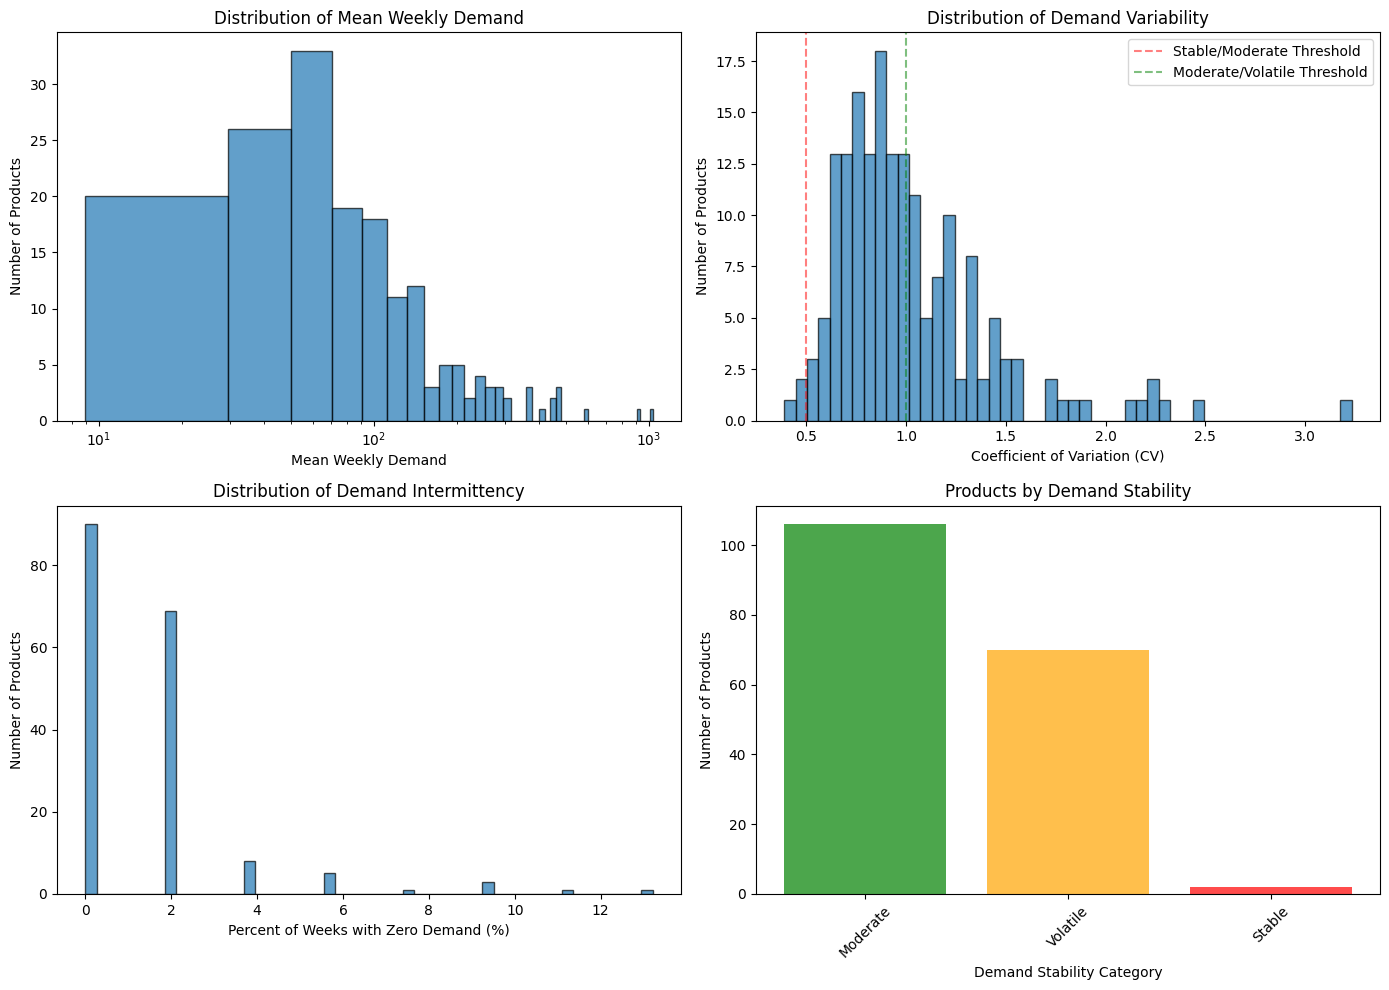

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of mean demand
axes[0, 0].hist(product_summary['Mean_Demand'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Mean Weekly Demand')
axes[0, 0].set_ylabel('Number of Products')
axes[0, 0].set_title('Distribution of Mean Weekly Demand')
axes[0, 0].set_xscale('log')

# Distribution of demand CV
axes[0, 1].hist(product_summary['Demand_CV'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Coefficient of Variation (CV)')
axes[0, 1].set_ylabel('Number of Products')
axes[0, 1].set_title('Distribution of Demand Variability')
axes[0, 1].axvline(x=0.5, color='r', linestyle='--', alpha=0.5, label='Stable/Moderate Threshold')
axes[0, 1].axvline(x=1.0, color='g', linestyle='--', alpha=0.5, label='Moderate/Volatile Threshold')
axes[0, 1].legend()

# Distribution of intermittency
axes[1, 0].hist(product_summary['Demand_Intermittency'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Percent of Weeks with Zero Demand (%)')
axes[1, 0].set_ylabel('Number of Products')
axes[1, 0].set_title('Distribution of Demand Intermittency')

# Demand stability categories
stability_counts = product_summary['Demand_Stability'].value_counts()
axes[1, 1].bar(stability_counts.index, stability_counts.values, color=['green', 'orange', 'red'], alpha=0.7)
axes[1, 1].set_xlabel('Demand Stability Category')
axes[1, 1].set_ylabel('Number of Products')
axes[1, 1].set_title('Products by Demand Stability')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/demand_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
model_data = weekly_complete.copy()

# Sort for feature creation
model_data = model_data.sort_values(['StockCode', 'Year', 'Week_Num']).reset_index(drop=True)


FEATURE ENGINEERING

In [ ]:
print("Creating lag features...")

lags = [1, 2, 3, 4, 8, 12]  # lags in weeks

for lag in lags:
    model_data[f'Demand_Lag_{lag}'] = model_data.groupby('StockCode')['Weekly_Demand'].shift(lag)
    model_data[f'Revenue_Lag_{lag}'] = model_data.groupby('StockCode')['Weekly_Revenue'].shift(lag)

Creating lag features...


In [ ]:
print("Creating rolling statistics...")

windows = [4, 8, 12]  # rolling windows in weeks

for window in windows:
    # Rolling mean
    model_data[f'Demand_Rolling_Mean_{window}'] = (
        model_data.groupby('StockCode')['Weekly_Demand']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    
    # Rolling max
    model_data[f'Demand_Rolling_Max_{window}'] = (
        model_data.groupby('StockCode')['Weekly_Demand']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).max())
    )
    
    # Rolling min
    model_data[f'Demand_Rolling_Min_{window}'] = (
        model_data.groupby('StockCode')['Weekly_Demand']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).min())
    )
    
    # Rolling standard deviation
    model_data[f'Demand_Rolling_Std_{window}'] = (
        model_data.groupby('StockCode')['Weekly_Demand']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())
    )

Creating rolling statistics...


In [ ]:
print("Creating seasonal features...")

# Week of year (1-52)
model_data['Week_Of_Year'] = model_data['Week_Num']

# Month (derived from week - approximate)
model_data['Month'] = np.ceil(model_data['Week_Num'] / 4).astype(int)
model_data['Month'] = model_data['Month'].clip(1, 12)

# Quarter
model_data['Quarter'] = model_data['Month'].apply(lambda x: (x-1)//3 + 1)

# Holiday season indicator (weeks with Christmas/New Year)
model_data['Is_Holiday_Season'] = ((model_data['Week_Num'] >= 48) | (model_data['Week_Num'] <= 2)).astype(int)

# Summer season indicator
model_data['Is_Summer'] = ((model_data['Week_Num'] >= 22) & (model_data['Week_Num'] <= 35)).astype(int)

# Month as cyclical features (sin/cos transformation)
model_data['Month_Sin'] = np.sin(2 * np.pi * model_data['Month'] / 12)
model_data['Month_Cos'] = np.cos(2 * np.pi * model_data['Month'] / 12)

# Week as cyclical
model_data['Week_Sin'] = np.sin(2 * np.pi * model_data['Week_Num'] / 52)
model_data['Week_Cos'] = np.cos(2 * np.pi * model_data['Week_Num'] / 52)


Creating seasonal features...


In [ ]:
print("Creating price features...")

# Calculate average price per product (using original transaction data)
product_avg_price = df_clean.groupby('StockCode')['Price'].mean().reset_index()
product_avg_price.columns = ['StockCode', 'Avg_Price']

# Get price per transaction to see variations
price_variation = df_clean.groupby(['StockCode', 'Date'])['Price'].first().reset_index()
price_variation['YearWeek'] = price_variation['Date'].dt.year.astype(str) + '-W' + price_variation['Date'].dt.isocalendar().week.astype(str).str.zfill(2)
weekly_price = price_variation.groupby(['StockCode', 'YearWeek'])['Price'].mean().reset_index()
weekly_price.columns = ['StockCode', 'YearWeek', 'Weekly_Avg_Price']

# Merge with model data
model_data = model_data.merge(weekly_price, on=['StockCode', 'YearWeek'], how='left')
model_data = model_data.merge(product_avg_price, on='StockCode', how='left')

# Fill missing prices with product average
model_data['Weekly_Avg_Price'] = model_data['Weekly_Avg_Price'].fillna(model_data['Avg_Price'])

# Price relative to average
model_data['Price_Ratio'] = model_data['Weekly_Avg_Price'] / model_data['Avg_Price']

# Price change features
model_data['Price_Change_1w'] = model_data.groupby('StockCode')['Weekly_Avg_Price'].pct_change(1)
model_data['Price_Change_4w'] = model_data.groupby('StockCode')['Weekly_Avg_Price'].pct_change(4)

Creating price features...


In [ ]:
print("Creating promotion indicators...")

# Calculate expected demand (rolling median)
model_data['Demand_Rolling_Median_8'] = (
    model_data.groupby('StockCode')['Weekly_Demand']
    .transform(lambda x: x.shift(1).rolling(8, min_periods=1).median())
)

# Calculate demand ratio (current vs expected)
model_data['Demand_vs_Expected'] = model_data['Weekly_Demand'] / (model_data['Demand_Rolling_Median_8'] + 1)

# Promotion indicator: demand > 2x expected and above minimum threshold
model_data['Is_Promotion'] = (
    (model_data['Demand_vs_Expected'] > 2.0) & 
    (model_data['Weekly_Demand'] > model_data['Weekly_Demand'].quantile(0.75))
).astype(int)

# Strong promotion indicator
model_data['Is_Strong_Promotion'] = (
    (model_data['Demand_vs_Expected'] > 3.0) & 
    (model_data['Weekly_Demand'] > model_data['Weekly_Demand'].quantile(0.9))
).astype(int)

Creating promotion indicators...


In [ ]:
for window in [4, 8]:
    model_data[f'Avg_Customers_Rolling_{window}'] = (
        model_data.groupby('StockCode')['Avg_Daily_Customers']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

# Transaction intensity
model_data['Transactions_Per_Customer'] = model_data['Total_Transactions'] / (model_data['Avg_Daily_Customers'] + 1)

In [ ]:
missing_after = model_data.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

print("Missing values after feature engineering:")
print(missing_after)

Missing values after feature engineering:
Demand_Lag_12              2136
Revenue_Lag_12             2136
Demand_Lag_8               1424
Revenue_Lag_8              1424
Price_Change_4w             712
Demand_Lag_4                712
Revenue_Lag_4               712
Demand_Lag_3                534
Revenue_Lag_3               534
Demand_Rolling_Std_12       356
Demand_Rolling_Std_4        356
Revenue_Lag_2               356
Demand_Lag_2                356
Demand_Rolling_Std_8        356
Demand_Rolling_Max_12       178
Avg_Customers_Rolling_4     178
Demand_vs_Expected          178
Demand_Rolling_Median_8     178
Price_Change_1w             178
Demand_Rolling_Min_12       178
Demand_Lag_1                178
Demand_Rolling_Mean_12      178
Demand_Rolling_Min_8        178
Demand_Rolling_Max_8        178
Demand_Rolling_Mean_8       178
Revenue_Lag_1               178
Demand_Rolling_Min_4        178
Demand_Rolling_Max_4        178
Demand_Rolling_Mean_4       178
Avg_Customers_Rolling_8     17

In [ ]:
lag_cols = [col for col in model_data.columns if 'Lag' in col]
for col in lag_cols:
    model_data[col] = model_data[col].fillna(0)

# For rolling stats, fill with forward fill then 0
rolling_cols = [col for col in model_data.columns if 'Rolling' in col]
for col in rolling_cols:
    model_data[col] = model_data.groupby('StockCode')[col].transform(lambda x: x.ffill()) 
    model_data[col] = model_data[col].fillna(0)

# For price change features, fill with 0
price_change_cols = [col for col in model_data.columns if 'Price_Change' in col]
for col in price_change_cols:
    model_data[col] = model_data[col].fillna(0)

# For other columns
model_data['Avg_Customers_Rolling_4'] = model_data['Avg_Customers_Rolling_4'].fillna(0)
model_data['Avg_Customers_Rolling_8'] = model_data['Avg_Customers_Rolling_8'].fillna(0)
model_data['Transactions_Per_Customer'] = model_data['Transactions_Per_Customer'].fillna(0)

# Verify no missing values remain
print(f"\nRemaining missing values: {model_data.isnull().sum().sum()}")


Remaining missing values: 178


In [ ]:
model_data['Demand_vs_Expected'] = model_data['Demand_vs_Expected'].fillna(1.0)

In [ ]:
model_data.isnull().sum()

YearWeek                     0
Year                         0
Week_Num                     0
StockCode                    0
Weekly_Demand                0
Weekly_Revenue               0
Avg_Daily_Customers          0
Total_Transactions           0
Days_With_Sales              0
Demand_Per_Active_Day        0
Zero_Demand_Week             0
Week_Index                   0
Demand_Lag_1                 0
Revenue_Lag_1                0
Demand_Lag_2                 0
Revenue_Lag_2                0
Demand_Lag_3                 0
Revenue_Lag_3                0
Demand_Lag_4                 0
Revenue_Lag_4                0
Demand_Lag_8                 0
Revenue_Lag_8                0
Demand_Lag_12                0
Revenue_Lag_12               0
Demand_Rolling_Mean_4        0
Demand_Rolling_Max_4         0
Demand_Rolling_Min_4         0
Demand_Rolling_Std_4         0
Demand_Rolling_Mean_8        0
Demand_Rolling_Max_8         0
Demand_Rolling_Min_8         0
Demand_Rolling_Std_8         0
Demand_R

In [ ]:
feature_dict = pd.DataFrame({
    'Feature': model_data.columns.tolist(),
    'Type': [
        'target' if col == 'Weekly_Demand' else
        'time' if col in ['Year', 'Week_Num', 'YearWeek', 'Week_Index', 'Date', 'Week_Start_Date', 'Week_End_Date'] else
        'product_id' if col == 'StockCode' else
        'lag' if 'Lag' in col else
        'rolling' if 'Rolling' in col else
        'seasonal' if any(x in col for x in ['Month', 'Quarter', 'Week_Of_Year', 'Sin', 'Cos', 'Holiday', 'Summer']) else
        'price' if 'Price' in col else
        'promotion' if 'Promotion' in col else
        'customer' if any(x in col for x in ['Customers', 'Transactions']) else
        'other' for col in model_data.columns
    ],
    'Description': [
        'Weekly demand (target variable) - sum of quantities sold' if col == 'Weekly_Demand' else
        'Product stock code' if col == 'StockCode' else
        f'Demand lagged by {col.split("_")[-1]} weeks' if 'Lag' in col and 'Demand' in col else
        f'Revenue lagged by {col.split("_")[-1]} weeks' if 'Lag' in col and 'Revenue' in col else
        f'{col.split("_")[-2]} {col.split("_")[-1]}-week rolling average of demand' if 'Rolling_Mean' in col else
        f'{col.split("_")[-2]} {col.split("_")[-1]}-week rolling maximum of demand' if 'Rolling_Max' in col else
        f'{col.split("_")[-2]} {col.split("_")[-1]}-week rolling minimum of demand' if 'Rolling_Min' in col else
        f'{col.split("_")[-2]} {col.split("_")[-1]}-week rolling standard deviation of demand' if 'Rolling_Std' in col else
        'Week number within year' if col == 'Week_Num' else
        'Approximate month derived from week' if col == 'Month' else
        'Quarter of year' if col == 'Quarter' else
        'Indicator for holiday season (weeks 48-52, 1-2)' if col == 'Is_Holiday_Season' else
        'Indicator for summer season (weeks 22-35)' if col == 'Is_Summer' else
        'Cyclical sine transformation of month' if col == 'Month_Sin' else
        'Cyclical cosine transformation of month' if col == 'Month_Cos' else
        'Cyclical sine transformation of week' if col == 'Week_Sin' else
        'Cyclical cosine transformation of week' if col == 'Week_Cos' else
        'Average price of product across all transactions' if col == 'Avg_Price' else
        'Average price in current week' if col == 'Weekly_Avg_Price' else
        'Ratio of weekly price to average price' if col == 'Price_Ratio' else
        '1-week percentage price change' if col == 'Price_Change_1w' else
        '4-week percentage price change' if col == 'Price_Change_4w' else
        '8-week rolling median of demand' if col == 'Demand_Rolling_Median_8' else
        'Ratio of current demand to expected (rolling median)' if col == 'Demand_vs_Expected' else
        'Binary indicator: 1 if demand > 2x expected' if col == 'Is_Promotion' else
        'Binary indicator: 1 if demand > 3x expected' if col == 'Is_Strong_Promotion' else
        f'{col.replace("_", " ").lower()}' for col in model_data.columns
    ]
})

print(f"Feature dictionary created with {len(feature_dict)} features")
print(feature_dict.head(10))

Feature dictionary created with 57 features
                 Feature        Type  \
0               YearWeek        time   
1                   Year        time   
2               Week_Num        time   
3              StockCode  product_id   
4          Weekly_Demand      target   
5         Weekly_Revenue       other   
6    Avg_Daily_Customers    customer   
7     Total_Transactions    customer   
8        Days_With_Sales       other   
9  Demand_Per_Active_Day       other   

                                         Description  
0                                           yearweek  
1                                               year  
2                            Week number within year  
3                                 Product stock code  
4  Weekly demand (target variable) - sum of quant...  
5                                     weekly revenue  
6                                avg daily customers  
7                                 total transactions  
8                   

In [ ]:
weekly_complete.to_csv('../data/processed/weekly_demand_complete.csv', index=False)
print("Saved: weekly_demand_complete.csv")

Saved: weekly_demand_complete.csv


In [ ]:
model_data.to_csv('../data/processed/modeling_data.csv', index=False)
print("Saved: modeling_data.csv")

Saved: modeling_data.csv


In [ ]:
product_summary.to_csv('../reports/summary_stats/product_summary.csv', index=False)
print("Saved: product_summary.csv")

Saved: product_summary.csv


In [ ]:
feature_dict.to_csv('../reports/summary_stats/feature_dictionary.csv', index=False)
print("Saved: feature_dictionary.csv")

Saved: feature_dictionary.csv


In [ ]:
all_weeks_sorted = sorted(model_data['YearWeek'].unique())
n_weeks = len(all_weeks_sorted)
train_cut = int(n_weeks * 0.7)
val_cut = int(n_weeks * 0.85)

train_weeks = all_weeks